In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input

2026-04-21 09:40:12.865020: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-21 09:40:13.062822: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776757213.132043     657 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776757213.153478     657 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776757213.315239     657 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
!nvidia-smi

Tue Apr 21 09:40:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.45.03              Driver Version: 595.71         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        On  |   00000000:01:00.0  On |                  N/A |
|  0%   27C    P8             30W /  390W |     375MiB /  24576MiB |      7%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import os


def load_paths(filepath):
    lines = []
    with open(filepath, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]
    
    base_dir = os.path.dirname(filepath) + '/HR/' + lines[0]
    seq_count = len(os.listdir(base_dir))

    result = [""] * seq_count * len(lines) * 7
    print(len(result))
    for i, line in enumerate(lines):
        for j in range(seq_count):
            for k in range(7):
                index = i * seq_count * 7 + j * 7 + k
                result[index] = os.path.join(f"{line}/{j}/im{k+1}.png")
    return result




In [5]:
train_paths = load_paths('/mnt/c/Users/henrik/Downloads/vimeo90k_upscale/train.txt')
val_paths = load_paths('/mnt/c/Users/henrik/Downloads/vimeo90k_upscale/test.txt')

1356852
164304


In [6]:
import tensorflow as tf
import os

def create_sr_dataset(
    root_path: str, 
    relative_paths: list[str], 
    batch_size: int = 32,
    is_training: bool = True,
    shuffle_buffer_size: int = 1000
):
    """
    Creates a lazy tf.data.Dataset for Super Resolution.
    
    Args:
        root_path: The base directory containing 'LR' and 'HR' folders.
        relative_paths: List of filenames/relative paths of the images.
        batch_size: The batch size for the dataset.
        is_training: If True, shuffles the dataset. If False, keeps original order for validation/testing.
        shuffle_buffer_size: The number of elements to maintain in the shuffle buffer.
    """
    paths_ds = tf.data.Dataset.from_tensor_slices(relative_paths)
    
    # Shuffle early in the pipeline if this is a training dataset
    if is_training:
        # Buffer size should ideally be larger than the batch size or the full dataset size
        # if memory permits, to ensure true randomness.
        paths_ds = paths_ds.shuffle(buffer_size=shuffle_buffer_size, reshuffle_each_iteration=True)
    
    def process_path(rel_path):
        # Construct the full paths by joining the root, subfolder, and relative path
        lr_path = tf.strings.join([root_path, 'LR', rel_path], separator=os.sep)
        hr_path = tf.strings.join([root_path, 'HR', rel_path], separator=os.sep)
        
        # Read the raw files (lazy loading)
        lr_img = tf.io.read_file(lr_path)
        hr_img = tf.io.read_file(hr_path)
        
        # Decode the images (adjust channels to 1 if using grayscale)
        lr_img = tf.image.decode_image(lr_img, channels=3, expand_animations=False)
        hr_img = tf.image.decode_image(hr_img, channels=3, expand_animations=False)
        
        # Convert to float32 and normalize to [0, 1] range
        lr_img = tf.cast(lr_img, tf.float32) / 255.0
        hr_img = tf.cast(hr_img, tf.float32) / 255.0
        
        return lr_img, hr_img

    # Use map to lazily load and transform the images automatically
    dataset = paths_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Batch the dataset
    dataset = dataset.batch(batch_size, drop_remainder=is_training)
    
    # Prefetch data to the GPU/Accelerator to prevent I/O bottlenecks
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return dataset

In [7]:
root_dir = "/mnt/c/Users/henrik/Downloads/vimeo90k_upscale/"
train_files = train_paths
val_files = val_paths

# Training dataset (Shuffled and drops incomplete batches)
train_ds = create_sr_dataset(root_dir, train_files, batch_size=32, is_training=True)
# 
# # Validation dataset (Not shuffled, keeps all data)
val_ds = create_sr_dataset(root_dir, val_files, batch_size=16, is_training=False)

I0000 00:00:1776757230.648887     657 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21764 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


In [8]:
import matplotlib.pyplot as plt

def visualize_dataset_samples(dataset, num_samples=3):
    """
    Takes a single batch from the dataset and plots the LR and HR images side-by-side.
    
    Args:
        dataset: A tf.data.Dataset object yielding (lr_images, hr_images).
        num_samples: The number of image pairs to display from the batch.
    """
    # .take(1) grabs just the first batch from the dataset
    for lr_batch, hr_batch in dataset.take(1):
        
        # Ensure we don't try to plot more samples than exist in the batch
        n = min(num_samples, lr_batch.shape[0])
        
        # Create a figure with 'n' rows and 2 columns
        fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(10, 4 * n))
        
        # If there's only 1 sample, axes is a 1D array. We wrap it to keep indexing consistent.
        if n == 1:
            axes = [axes]
            
        for i in range(n):
            # Plot Low Resolution image
            ax_lr = axes[i][0]
            # .numpy() converts the TensorFlow tensor back to a numpy array for matplotlib
            ax_lr.imshow(lr_batch[i].numpy())
            ax_lr.set_title(f"Low Resolution (LR) - {lr_batch[i].shape}")
            ax_lr.axis('off')  # Hide the axes ticks
            
            # Plot High Resolution image
            ax_hr = axes[i][1]
            ax_hr.imshow(hr_batch[i].numpy())
            ax_hr.set_title(f"High Resolution (HR) - {hr_batch[i].shape}")
            ax_hr.axis('off')
            
        plt.tight_layout()
        plt.show()

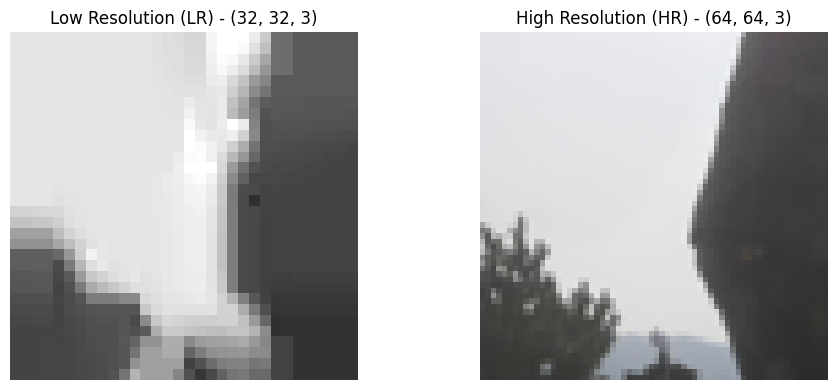

2026-04-21 09:40:40.058362: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [9]:
visualize_dataset_samples(val_ds, num_samples=1)

In [10]:
import tensorflow as tf

def create_dummy_model(x_width, x_height, y_width, y_height, interpolation="bilinear"):
    inp = tf.keras.layers.Input(shape=(x_height, x_width, 3))
    out = tf.keras.layers.Resizing(y_height, y_width, interpolation=interpolation)(inp)
    model = tf.keras.Model(inputs=inp, outputs=out)
    return model
dummy_model = create_dummy_model(32, 32, 64, 64)

# 2. Define a custom metric for PSNR
def psnr_metric(y_true, y_pred):
    # Calculate PSNR manually to avoid Keras graph-mode Assert issues in tf.image.psnr
    # We add a small epsilon (1e-10) to the MSE to prevent the result from becoming 'inf'
    mse = tf.reduce_mean(tf.square(y_true - y_pred), axis=[1, 2, 3])
    # PSNR = 10 * log10(max_val^2 / MSE). Here max_val is 1.0.
    # tf.math.log is natural log, so we divide by log(10) to get log10.
    return 10.0 * (tf.math.log(1.0 / (mse + 1e-10)) / tf.math.log(10.0))

# 3. Compile the model with MSE loss and our PSNR metric
dummy_model.compile(
    optimizer='adam', # Optimizer isn't actually used since no weights, but required for compile
    loss='mse',
    metrics=[psnr_metric]
)


In [13]:
dummy_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:

print("Evaluating linear upscaling dummy model on the entire validation dataset...")

# 4. Use Keras built-in .evaluate() on the validation dataset (val_ds)
evaluation_results = dummy_model.evaluate(val_ds)

print("-" * 30)
print(f"Validation Mean Squared Error (Loss): {evaluation_results[0]:.4f}")
print(f"Validation Mean PSNR:                 {evaluation_results[1]:.2f} dB")

In [11]:
dummy_model.save('dummy_model.keras')

Visualizing one upscaled example from the validation set...


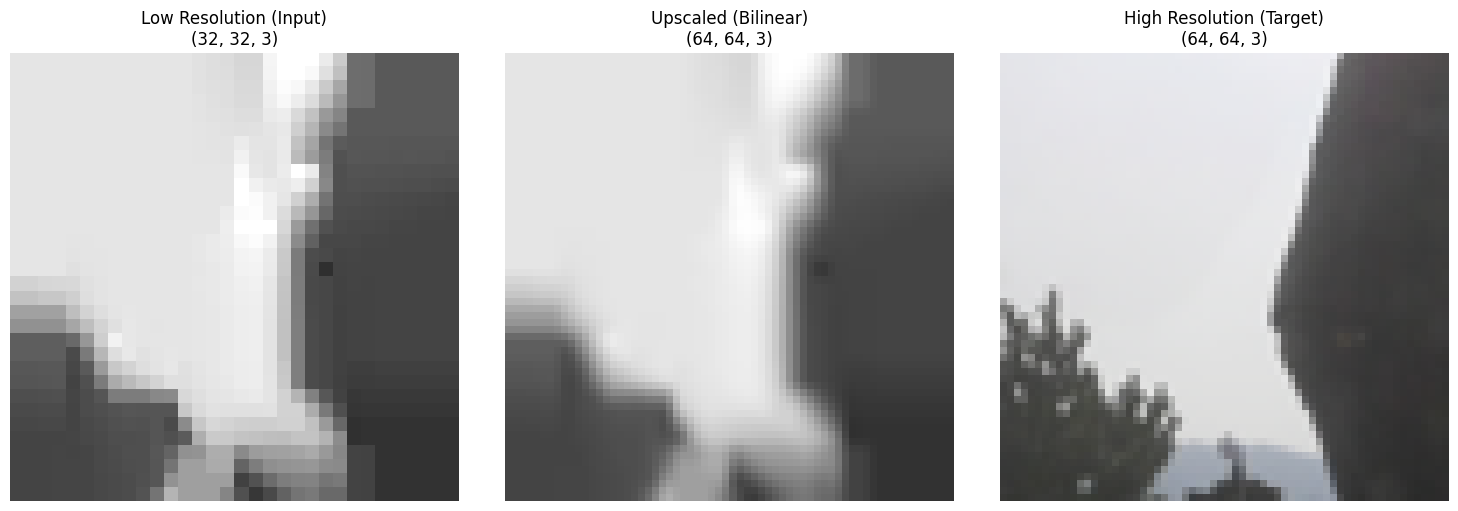

In [11]:
import matplotlib.pyplot as plt

print("Visualizing one upscaled example from the validation set...")

# Take 1 batch from the validation dataset
for lr_batch, hr_batch in val_ds.take(1):
    # Predict (upscale) using the dummy model
    predicted_hr = dummy_model(lr_batch)
    
    # We'll just display the very first image in the batch
    lr_img = lr_batch[0].numpy()
    hr_img = hr_batch[0].numpy()
    
    # Clip the prediction to [0, 1] range to ensure matplotlib displays it correctly
    pred_img = tf.clip_by_value(predicted_hr[0], 0.0, 1.0).numpy()
    
    plt.figure(figsize=(15, 5))
    
    # 1. Plot Low Resolution (Input)
    plt.subplot(1, 3, 1)
    plt.imshow(lr_img)
    plt.title(f"Low Resolution (Input)\n{lr_img.shape}")
    plt.axis('off')
    
    # 2. Plot Upscaled (Dummy Model Output)
    plt.subplot(1, 3, 2)
    plt.imshow(pred_img)
    plt.title(f"Upscaled (Bilinear)\n{pred_img.shape}")
    plt.axis('off')
    
    # 3. Plot High Resolution (Ground Truth)
    plt.subplot(1, 3, 3)
    plt.imshow(hr_img)
    plt.title(f"High Resolution (Target)\n{hr_img.shape}")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Process only the first batch then break
    break

In [12]:
def create_larger_upscaler(input_shape=(32, 32, 3), scale_factor=2):
    """
    Creates a larger image upscaling neural network (under 1MB).
    
    Args:
        input_shape: Shape of the input image (height, width, channels). 
                     (None, None, 3) allows for dynamic image sizes.
        scale_factor: Integer defining how much to upscale the image (e.g., 2, 3, 4).
                     
    Returns:
        A compiled Keras model.
    """
    inputs = layers.Input(shape=input_shape)
    
    # Feature extraction (more filters, deeper network)
    x = layers.Conv2D(64, (5, 5), activation='relu', padding='same')(inputs)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    
    # Spatial Upsampling
    x = layers.Resizing(64, 64, interpolation='bilinear')(x)
    
    # Post-upsampling refinement
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    
    # Image reconstruction
    channels = input_shape[-1] if len(input_shape) == 3 and input_shape[-1] is not None else 3
    outputs = layers.Conv2D(channels, (3, 3), activation='linear', padding='same')(x)
    
    model = models.Model(
        inputs=inputs, 
        outputs=outputs, 
        name=f'larger_upscaler_{scale_factor}x'
    )
    
    return model

model = create_larger_upscaler(input_shape=(32, 32, 3), scale_factor=2)
model.summary()

Model: "larger_upscaler_2x"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,379 (458.51 KB)

 Trainable params: 117,379 (458.51 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import os


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[psnr_metric]
)

# 1. Ensure the checkpoint directory exists
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "best_sr_model.keras")

# 2. Define the Callbacks
callbacks = [
    # Save the model whenever validation PSNR improves
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_psnr_metric", # We monitor our custom metric from compile()
        mode="max",                # We want maximum PSNR
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    
    # Reduce learning rate if validation loss stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,       # Halve the learning rate
        patience=3,       # Wait 3 epochs before reducing
        min_lr=1e-6,      # Minimum learning rate lower bound
        verbose=1
    ),
    
    # Stop training early if validation loss hasn't improved for a long time
    EarlyStopping(
        monitor="val_loss",
        patience=10,                      # Wait 10 epochs before stopping
        restore_best_weights=True,        # Automatically revert to the best epoch
        verbose=1
    )
]



print("Starting training...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=400,
    callbacks=callbacks
)

Starting training...
Epoch 1/400


I0000 00:00:1776194531.695389    1268 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


42400/42401 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0024 - psnr_metric: 30.0041
Epoch 1: val_psnr_metric improved from None to 29.63496, saving model to checkpoints/best_sr_model.keras

Epoch 1: finished saving model to checkpoints/best_sr_model.keras
42401/42401 ━━━━━━━━━━━━━━━━━━━━ 1366s 32ms/step - loss: 0.0021 - psnr_metric: 30.3728 - val_loss: 0.0024 - val_psnr_metric: 29.6350 - learning_rate: 0.0010
Epoch 2/400
42399/42401 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0020 - psnr_metric: 30.6852
Epoch 2: val_psnr_metric improved from 29.63496 to 29.76892, saving model to checkpoints/best_sr_model.keras

Epoch 2: finished saving model to checkpoints/best_sr_model.keras
42401/42401 ━━━━━━━━━━━━━━━━━━━━ 856s 20ms/step - loss: 0.0020 - psnr_metric: 30.6852 - val_loss: 0.0024 - val_psnr_metric: 29.7689 - learning_rate: 0.0010
Epoch 3/400
42400/42401 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0020 - psnr_metric: 30.7296
Epoch 3: val_psnr_metric did not improve from 29.76892
42401/42

KeyboardInterrupt: 

Visualizing one upscaled example from the validation set...


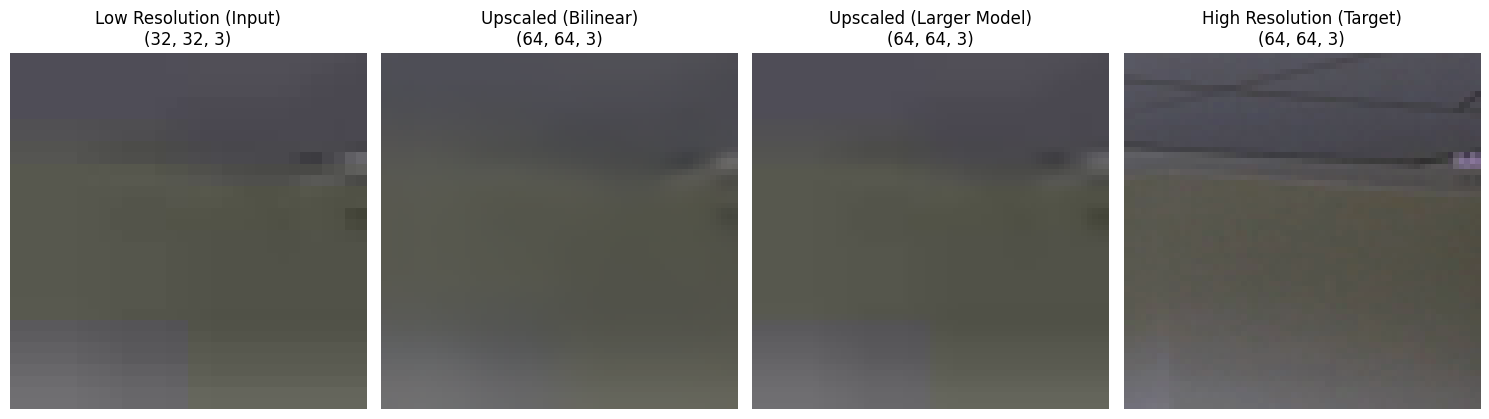

In [44]:
import matplotlib.pyplot as plt

print("Visualizing one upscaled example from the validation set...")

# Take 1 batch from the validation dataset, but shuffle first to get a random batch
for lr_batch, hr_batch in val_ds.shuffle(100).take(1):
    # Predict (upscale) using the dummy model
    predicted_hr = model(lr_batch)
    predicted_hr_2 = dummy_model(lr_batch)

    # We'll just display the very first image in the batch
    lr_img = lr_batch[0].numpy()
    hr_img = hr_batch[0].numpy()
    
    # Clip the prediction to [0, 1] range to ensure matplotlib displays it correctly
    pred_img = tf.clip_by_value(predicted_hr[0], 0.0, 1.0).numpy()
    pred_img_2 = tf.clip_by_value(predicted_hr_2[0], 0.0, 1.0).numpy()

    plt.figure(figsize=(15, 5))
    
    # 1. Plot Low Resolution (Input)
    plt.subplot(1, 4, 1)
    plt.imshow(lr_img)
    plt.title(f"Low Resolution (Input)\n{lr_img.shape}")
    plt.axis('off')
    
    # 2. Plot Upscaled (Dummy Model Output)
    plt.subplot(1, 4, 2)
    plt.imshow(pred_img)
    plt.title(f"Upscaled (Bilinear)\n{pred_img.shape}")
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(pred_img_2)
    plt.title(f"Upscaled (Larger Model)\n{pred_img_2.shape}")
    plt.axis('off')
    
    # 3. Plot High Resolution (Ground Truth)
    plt.subplot(1, 4, 4)
    plt.imshow(hr_img)
    plt.title(f"High Resolution (Target)\n{hr_img.shape}")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Process only the first batch then break
    break
